In [101]:
# Aiden Munger
# DJ Desmet's influence on my Spotify listening habits
# 4/23/24


from importlib.resources import files

import pandas as pd

spotify_files = [
    r"my_spotify_data\Spotify Extended Streaming History\Streaming_History_Audio_2022.json",
    r"my_spotify_data\Spotify Extended Streaming History\Streaming_History_Audio_2023.json",
    r"my_spotify_data\Spotify Extended Streaming History\Streaming_History_Audio_2024.json",
    r"my_spotify_data\Spotify Extended Streaming History\Streaming_History_Audio_2025.json",
    r"my_spotify_data\Spotify Extended Streaming History\Streaming_History_Audio_2026.json"
]

# Bring together all the data into one DataFrame
df = pd.concat([pd.read_json(f) for f in spotify_files], ignore_index=True)

df = df[df["master_metadata_track_name"].notna()]
# Convert ts to datetime
df["ts"] = pd.to_datetime(df["ts"])
# Convert ms_played to minutes
df["minutes_played"] = df["ms_played"] / 60000
df = df.drop(columns=["ip_addr", "spotify_track_uri"])

In [ ]:
# Get the cutoff date for DJ Desmet's influence
dj_date = pd.to_datetime("2025-09-15", utc=True)

# Resample to daily listening time
daily = df.set_index("ts").resample("D")["minutes_played"].sum()

# remove days with no listening to make the averages more meaningful
daily = daily[daily > 0]

# remove weekends to focus on workday listening habits
daily = daily[daily.index.dayofweek < 5]

before = daily[daily.index < dj_date]
after = daily[daily.index >= dj_date]

# Print the daily averages
print(f"Average daily minutes played before DJ: {before.mean():.2f}")
print(f"Average daily minutes played after DJ: {after.mean():.2f}")

Average daily minutes played before DJ: 53.94
Average daily minutes played after DJ: 168.05


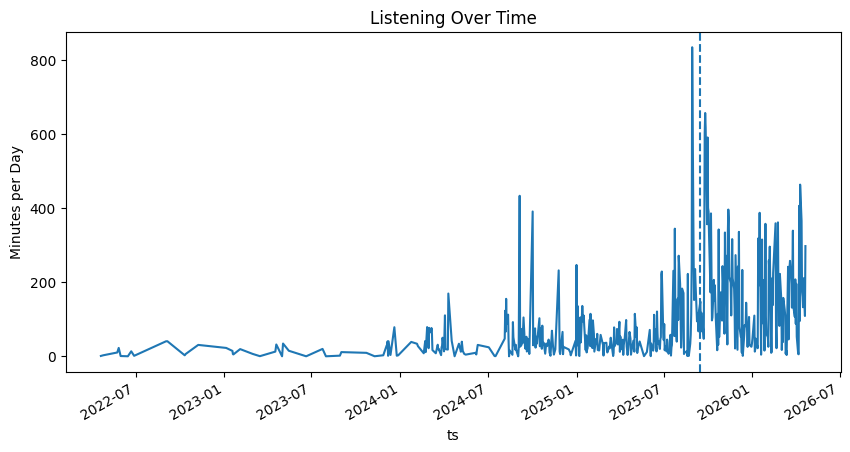

In [ ]:
import matplotlib.pyplot as plt

daily.plot(figsize=(10,5))
plt.axvline(dj_date, linestyle="--")
plt.title("Listening Over Time")
plt.ylabel("Minutes per Day")
plt.show()

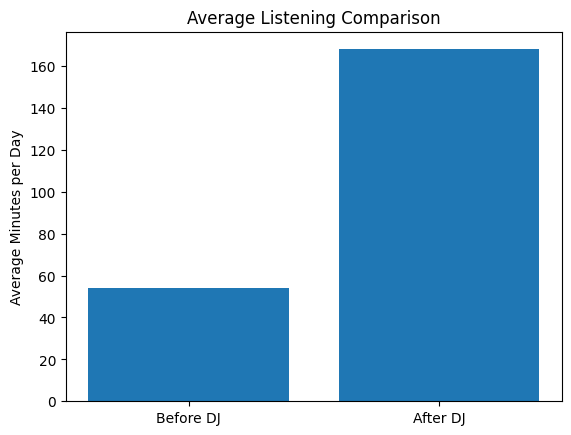

In [100]:
import numpy as np

means = [before.mean(), after.mean()]

plt.bar(["Before DJ", "After DJ"], means)
plt.ylabel("Average Minutes per Day")
plt.title("Average Listening Comparison")
plt.show()

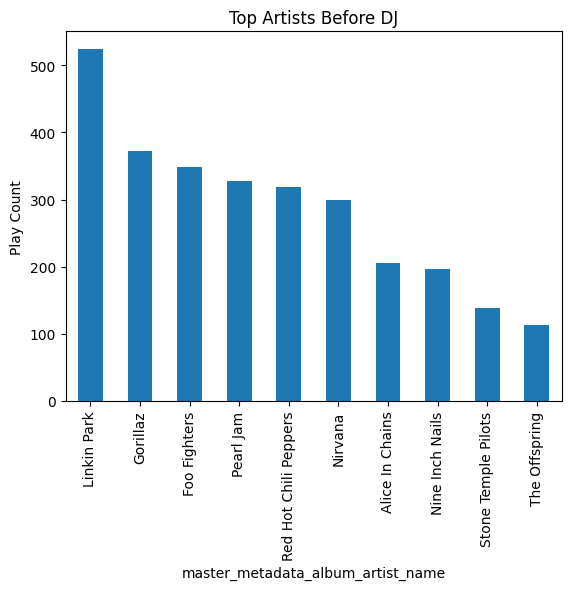

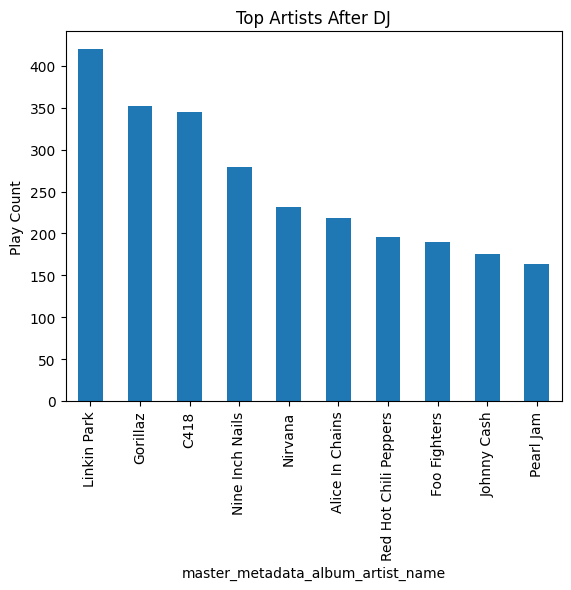

In [93]:
before_df = df[df["ts"] < dj_date]
after_df = df[df["ts"] >= dj_date]

top_before = before_df["master_metadata_album_artist_name"].value_counts().head(10)
top_after = after_df["master_metadata_album_artist_name"].value_counts().head(10)

top_before.plot(kind="bar", title="Top Artists Before DJ")
plt.ylabel("Play Count")
plt.show()

top_after.plot(kind="bar", title="Top Artists After DJ")
plt.ylabel("Play Count")
plt.show()

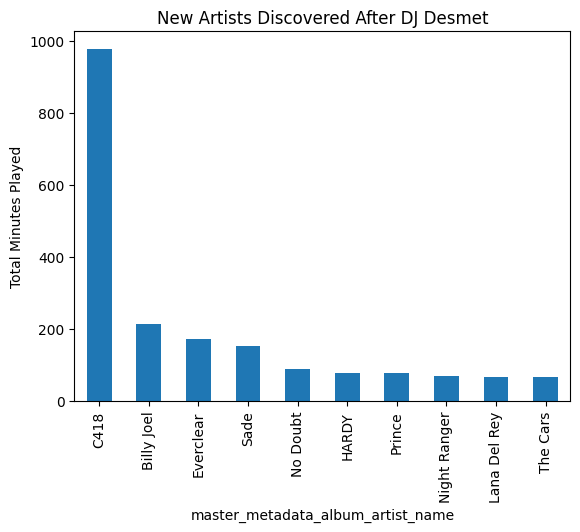

In [94]:
before_artists = set(before_df["master_metadata_album_artist_name"].dropna())
after_artists = set(after_df["master_metadata_album_artist_name"].dropna())
new_artists = after_artists - before_artists

new_artist_df = after_df[after_df["master_metadata_album_artist_name"].isin(new_artists)]

top_new = new_artist_df.groupby("master_metadata_album_artist_name")["minutes_played"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10)

top_new.plot(kind="bar", title="New Artists Discovered After DJ Desmet")
plt.ylabel("Total Minutes Played")
plt.show()

H0 (null): My average daily listening time did not change after becoming DJ DeSmet.

H1 (alt): My average daily listening time did change after becoming DJ Desmet.

In [96]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(before, after, equal_var=False)

print("Before avg:", before.mean())
print("After avg:", after.mean())
print("t-stat:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("The difference in listening time before and after DJ Desmet is statistically significant.")
else:
    print("The difference in listening time before and after DJ Desmet is not statistically significant.")



Before avg: 53.942405921052625
After avg: 168.05278278867104
t-stat: -9.564650147140476
p-value: 4.015331657717852e-18
The difference in listening time before and after DJ Desmet is statistically significant.


Because the p-value is far below the significance threshold, we reject the null hypothesis.